In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import (
    VarianceThreshold,
    chi2,
    f_classif,
    mutual_info_classif,
    SelectKBest
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [5]:
# ============================================================
# CELL 2 — Load Preprocessed Data from saved_data/
# ============================================================

LOAD_DIR = 'saved_data'

# Scaled versions → used for ANOVA, Pearson, Mutual Info
X_train_scaled = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')
X_test_scaled  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')

# Raw (unscaled) versions → used for Chi-Square
X_train_raw    = joblib.load(f'{LOAD_DIR}/X_train_raw.pkl')
X_test_raw     = joblib.load(f'{LOAD_DIR}/X_test_raw.pkl')

# Labels
y_train        = joblib.load(f'{LOAD_DIR}/y_train.pkl')
y_test         = joblib.load(f'{LOAD_DIR}/y_test.pkl')

# Feature names
feature_names  = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# Baseline results
baseline_results = joblib.load(f'{LOAD_DIR}/baseline_results.pkl')

# --- Convert to proper pandas objects ---
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names) if not isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names) if not isinstance(X_test_scaled,  pd.DataFrame) else X_test_scaled
X_train_raw    = pd.DataFrame(X_train_raw,    columns=feature_names) if not isinstance(X_train_raw,    pd.DataFrame) else X_train_raw
X_test_raw     = pd.DataFrame(X_test_raw,     columns=feature_names) if not isinstance(X_test_raw,     pd.DataFrame) else X_test_raw
y_train        = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train
y_test         = pd.Series(y_test)  if not isinstance(y_test,  pd.Series) else y_test

# --- Reset indices ---
for df in [X_train_scaled, X_test_scaled, X_train_raw, X_test_raw]:
    df.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# --- Combine train+test for filter scoring ---
X_full_scaled = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)
X_full_raw    = pd.concat([X_train_raw,    X_test_raw],    axis=0).reset_index(drop=True)
y_full        = pd.concat([y_train,        y_test],        axis=0).reset_index(drop=True)

print('✅ Data loaded successfully!')
print(f'   X_train_scaled : {X_train_scaled.shape}')
print(f'   X_test_scaled  : {X_test_scaled.shape}')
print(f'   X_train_raw    : {X_train_raw.shape}')
print(f'   X_test_raw     : {X_test_raw.shape}')
print(f'   X_full_scaled  : {X_full_scaled.shape}')
print(f'   y_train classes: {y_train.value_counts().to_dict()}')
print(f'   y_test  classes: {y_test.value_counts().to_dict()}')
print(f'   Total features : {len(feature_names)}')
print(f'   Feature names  : {feature_names}')

✅ Data loaded successfully!
   X_train_scaled : (262, 22)
   X_test_scaled  : (61, 22)
   X_train_raw    : (262, 22)
   X_test_raw     : (61, 22)
   X_full_scaled  : (323, 22)
   y_train classes: {1: 131, 0: 131}
   y_test  classes: {0: 33, 1: 28}
   Total features : 22
   Feature names  : ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6', 'thal_7', 'ca_1', 'ca_2', 'ca_3']


📊 METHOD 1: VARIANCE THRESHOLD
   Total features   : 22
   Features REMOVED : 2
   Features KEPT    : 20
   Removed          : ['thal_4', 'thal_5']


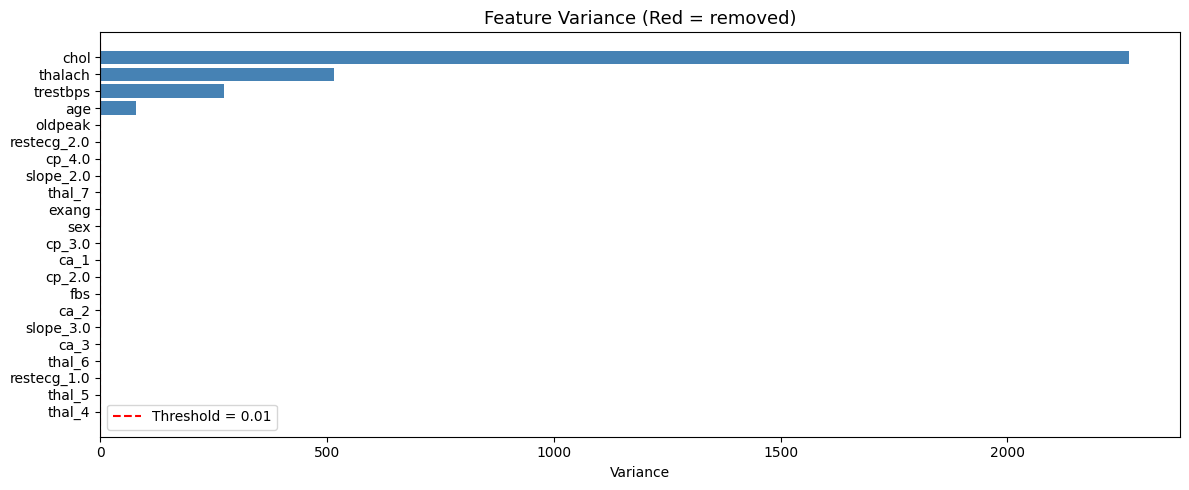


✅ Working shape after variance filter: (323, 20)


In [6]:
# ================================================================
# METHOD 1: VARIANCE THRESHOLD
# ================================================================
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_full_raw)

variance_mask         = selector_var.get_support()
low_variance_features = X_full_raw.columns[~variance_mask].tolist()
kept_after_variance   = X_full_raw.columns[variance_mask].tolist()

print("=" * 55)
print("📊 METHOD 1: VARIANCE THRESHOLD")
print("=" * 55)
print(f"   Total features   : {X_full_raw.shape[1]}")
print(f"   Features REMOVED : {len(low_variance_features)}")
print(f"   Features KEPT    : {len(kept_after_variance)}")
print(f"   Removed          : {low_variance_features}")

variances = X_full_raw.var().sort_values()
plt.figure(figsize=(12, 5))
colors = ['red' if v < 0.01 else 'steelblue' for v in variances]
plt.barh(variances.index, variances.values, color=colors)
plt.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.01')
plt.title('Feature Variance (Red = removed)', fontsize=13)
plt.xlabel('Variance')
plt.legend()
plt.tight_layout()
plt.show()

X_work_scaled = X_full_scaled[kept_after_variance].copy()
X_work_raw    = X_full_raw[kept_after_variance].copy()
print(f"\n✅ Working shape after variance filter: {X_work_scaled.shape}")

📊 METHOD 2: CHI-SQUARE TEST (Top 15)
  Feature  Chi2_Score      P_Value
  thalach  195.664172 1.845260e-44
  oldpeak   68.715796 1.137263e-16
   cp_4.0   39.905900 2.664970e-10
   thal_7   37.786551 7.892402e-10
    exang   36.698680 1.378728e-09
     chol   29.369670 5.980638e-08
   cp_3.0   27.548989 1.531654e-07
      age   22.616929 1.977346e-06
slope_2.0   21.515847 3.509168e-06
   cp_2.0   19.505943 1.002872e-05
     ca_2   14.288946 1.567828e-04
 trestbps   11.863895 5.723272e-04
     ca_1   11.775837 6.000453e-04
     ca_3   10.240683 1.373767e-03
      sex    6.731290 9.473607e-03

✅ Significant (p < 0.05): 15 / 20


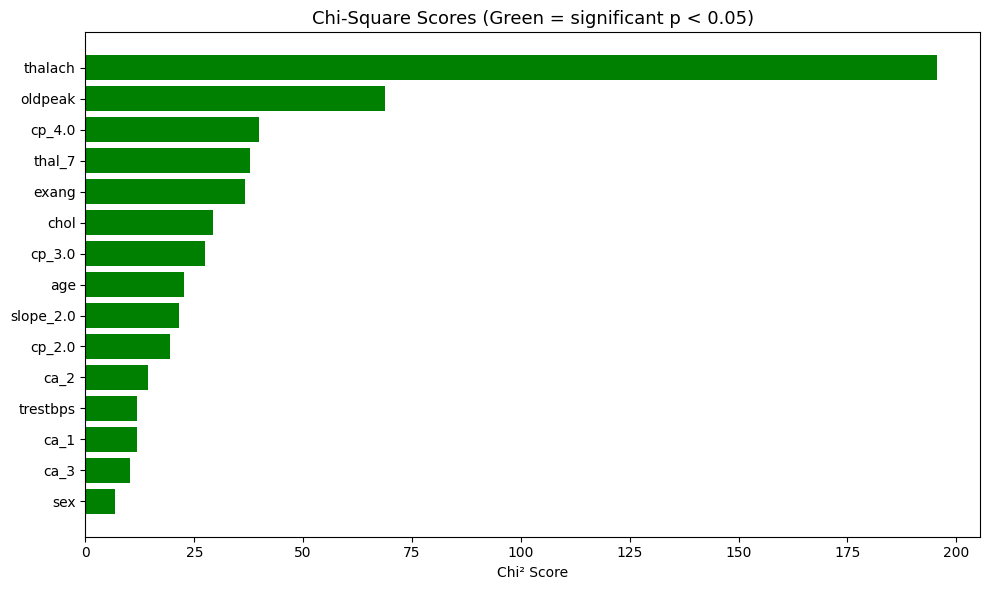

In [7]:
# ================================================================
# METHOD 2: CHI-SQUARE TEST
# ================================================================
X_chi2 = X_work_raw.clip(lower=0)
chi2_scores, chi2_pvalues = chi2(X_chi2, y_full)

chi2_df = pd.DataFrame({
    'Feature'   : X_work_raw.columns,
    'Chi2_Score': chi2_scores,
    'P_Value'   : chi2_pvalues
}).sort_values('Chi2_Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 2: CHI-SQUARE TEST (Top 15)")
print("=" * 55)
print(chi2_df.head(15).to_string(index=False))
print(f"\n✅ Significant (p < 0.05): {len(chi2_df[chi2_df['P_Value'] < 0.05])} / {len(chi2_df)}")

top_chi2 = chi2_df.head(15)
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'salmon' for p in top_chi2['P_Value']]
plt.barh(top_chi2['Feature'][::-1], top_chi2['Chi2_Score'][::-1], color=colors[::-1])
plt.title('Chi-Square Scores (Green = significant p < 0.05)', fontsize=13)
plt.xlabel('Chi² Score')
plt.tight_layout()
plt.show()

📊 METHOD 3: ANOVA F-TEST (Top 15)
    Feature   F_Score      P_Value
     cp_4.0 99.228344 1.521206e-20
     thal_7 74.316687 3.090394e-16
    oldpeak 72.375217 6.882087e-16
    thalach 68.506444 3.436447e-15
      exang 65.701001 1.114896e-14
  slope_2.0 46.513966 4.528642e-11
     cp_3.0 42.220973 3.108935e-10
     cp_2.0 24.700413 1.091622e-06
        sex 22.214174 3.639338e-06
       ca_2 17.006169 4.750132e-05
        age 16.582045 5.873851e-05
       ca_1 15.801262 8.695374e-05
       ca_3 11.228538 9.015904e-04
restecg_2.0  6.313927 1.246909e-02
   trestbps  5.776171 1.681175e-02

✅ Significant (p < 0.05): 15 / 20


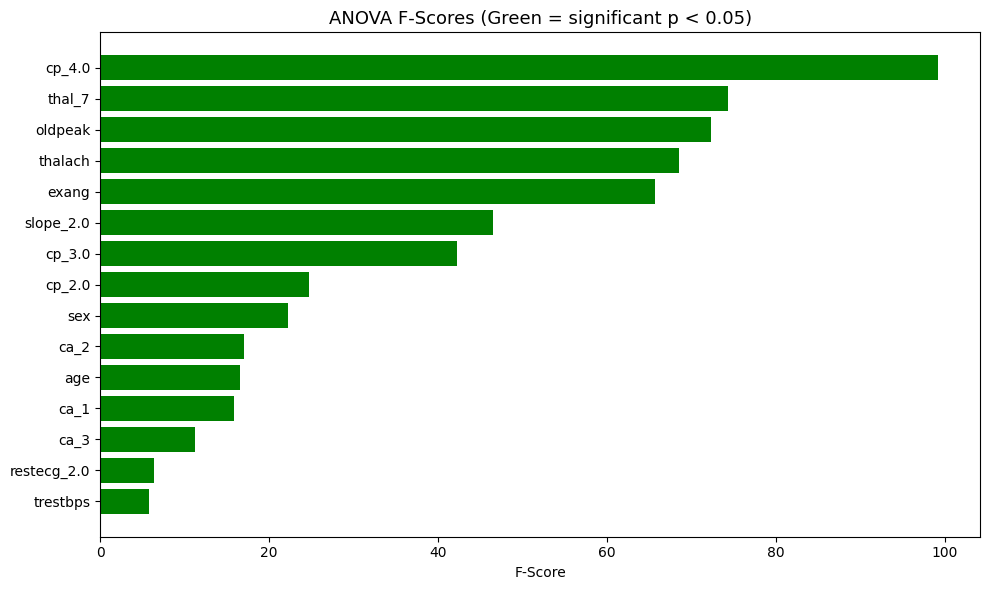

In [8]:
# ================================================================
# METHOD 3: ANOVA F-TEST
# ================================================================
f_scores, f_pvalues = f_classif(X_work_scaled, y_full)

anova_df = pd.DataFrame({
    'Feature': X_work_scaled.columns,
    'F_Score': f_scores,
    'P_Value': f_pvalues
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 3: ANOVA F-TEST (Top 15)")
print("=" * 55)
print(anova_df.head(15).to_string(index=False))
print(f"\n✅ Significant (p < 0.05): {len(anova_df[anova_df['P_Value'] < 0.05])} / {len(anova_df)}")

top_anova = anova_df.head(15)
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'salmon' for p in top_anova['P_Value']]
plt.barh(top_anova['Feature'][::-1], top_anova['F_Score'][::-1], color=colors[::-1])
plt.title('ANOVA F-Scores (Green = significant p < 0.05)', fontsize=13)
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

📊 METHOD 4: PEARSON CORRELATION WITH TARGET
    Feature  Correlation
     cp_4.0     0.485932
     thal_7     0.433581
    oldpeak     0.428935
    thalach     0.419381
      exang     0.412191
  slope_2.0     0.355758
     cp_3.0     0.340941
     cp_2.0     0.267302
        sex     0.254409
       ca_2     0.224306
        age     0.221630
       ca_1     0.216600
       ca_3     0.183841
restecg_2.0     0.138889
   trestbps     0.132952
       chol     0.099413
     thal_6     0.084748
restecg_1.0     0.057730
  slope_3.0     0.041758
        fbs     0.006309


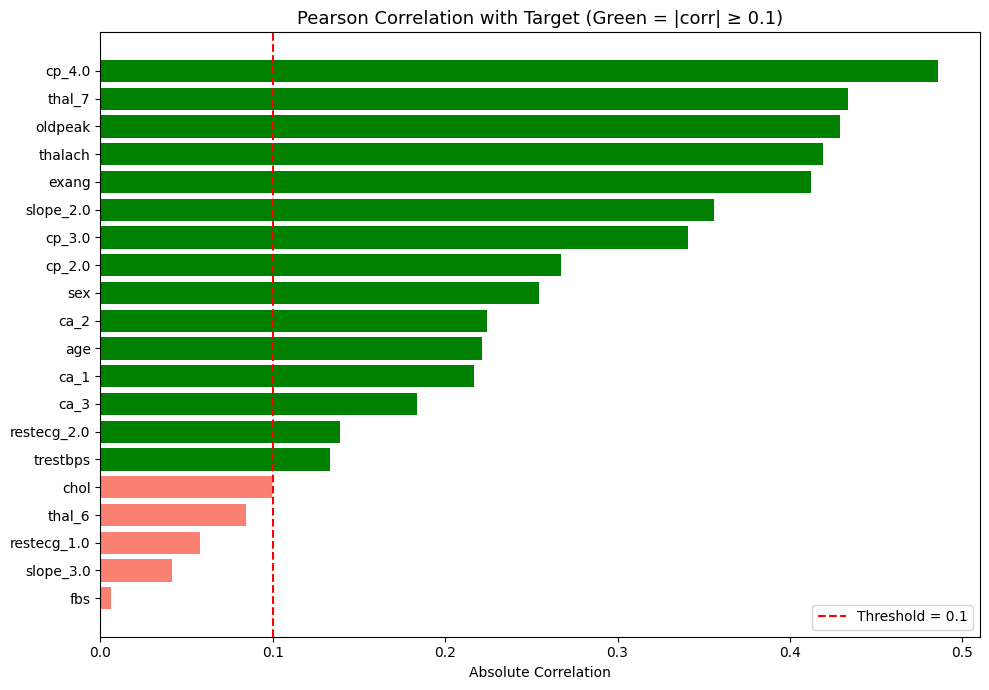

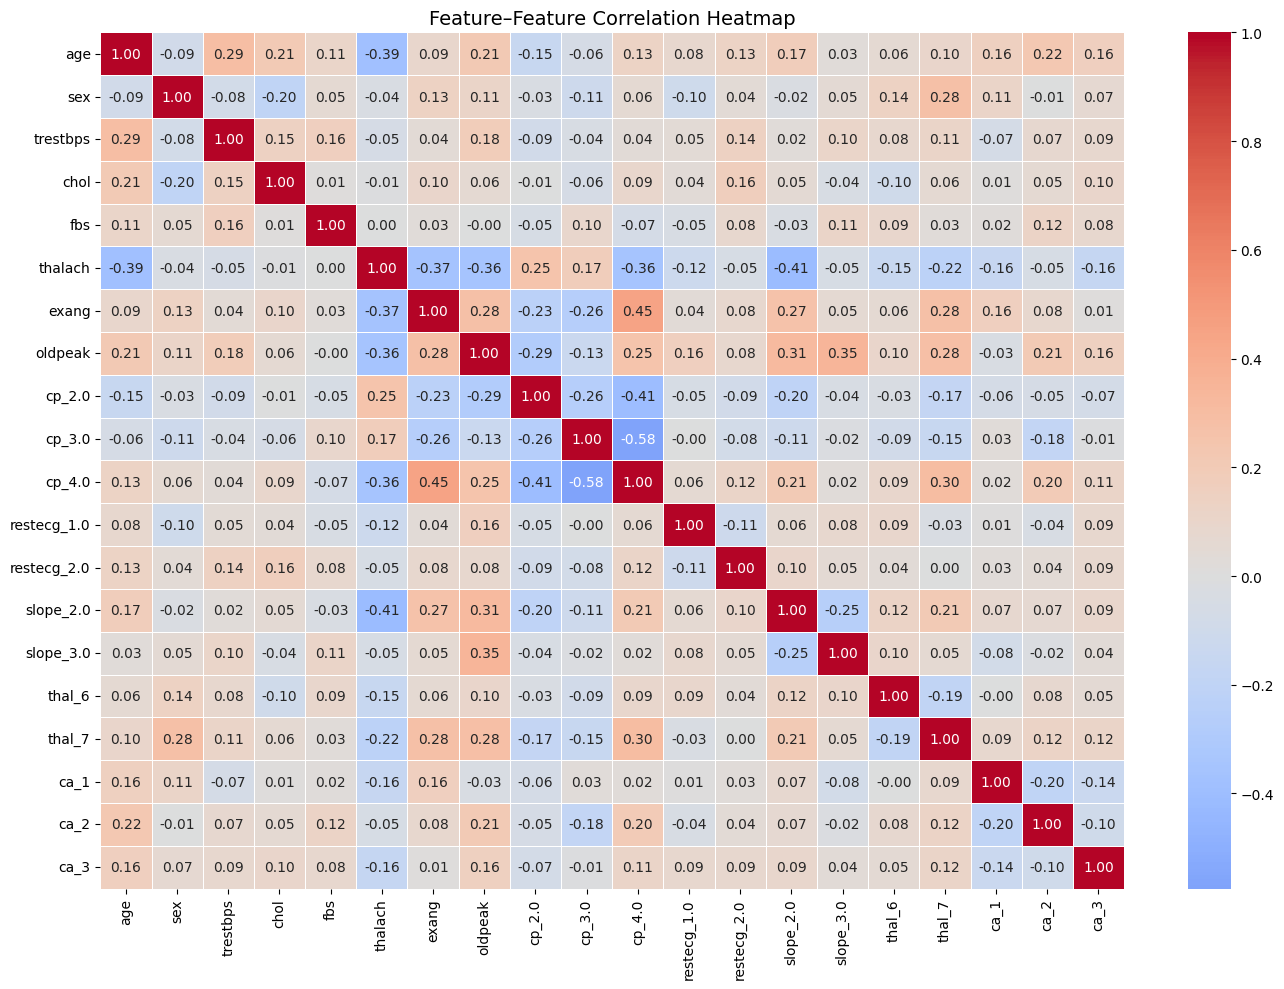

In [9]:
# ================================================================
# METHOD 4: PEARSON CORRELATION
# ================================================================
corr_series = X_work_scaled.corrwith(y_full).abs().sort_values(ascending=False)

corr_df = pd.DataFrame({
    'Feature'    : corr_series.index,
    'Correlation': corr_series.values
}).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 4: PEARSON CORRELATION WITH TARGET")
print("=" * 55)
print(corr_df.to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ['green' if c >= 0.1 else 'salmon' for c in corr_series.values]
plt.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1])
plt.axvline(x=0.1, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.1')
plt.title('Pearson Correlation with Target (Green = |corr| ≥ 0.1)', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(X_work_scaled.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature–Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

📊 METHOD 5: MUTUAL INFORMATION SCORES
    Feature  MI_Score
     cp_4.0  0.141271
    oldpeak  0.117429
      exang  0.085138
    thalach  0.082220
     thal_7  0.070360
       chol  0.068331
     cp_3.0  0.043949
  slope_3.0  0.040690
        sex  0.039849
     cp_2.0  0.034955
       ca_1  0.033901
        age  0.031341
restecg_1.0  0.029544
     thal_6  0.024867
  slope_2.0  0.021698
   trestbps  0.017790
       ca_3  0.009261
restecg_2.0  0.004663
        fbs  0.000000
       ca_2  0.000000


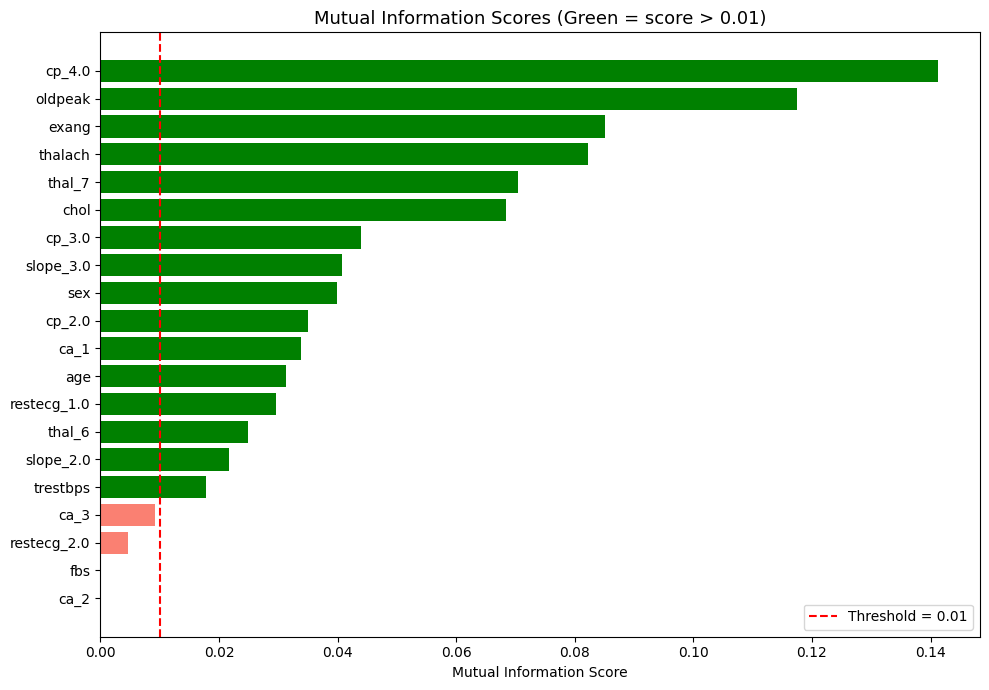

In [10]:
# ================================================================
# METHOD 5: MUTUAL INFORMATION
# ================================================================
mi_scores = mutual_info_classif(X_work_raw, y_full, random_state=42)

mi_df = pd.DataFrame({
    'Feature' : X_work_raw.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("📊 METHOD 5: MUTUAL INFORMATION SCORES")
print("=" * 55)
print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ['green' if s > 0.01 else 'salmon' for s in mi_df['MI_Score']]
plt.barh(mi_df['Feature'][::-1], mi_df['MI_Score'][::-1], color=colors[::-1])
plt.axvline(x=0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.01')
plt.title('Mutual Information Scores (Green = score > 0.01)', fontsize=13)
plt.xlabel('Mutual Information Score')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ================================================================
# METHOD 6: SelectKBest
# ================================================================
K = 10

skb_anova = SelectKBest(score_func=f_classif, k=K)
skb_anova.fit(X_work_scaled, y_full)
top_k_anova = X_work_scaled.columns[skb_anova.get_support()].tolist()

skb_mi = SelectKBest(score_func=mutual_info_classif, k=K)
skb_mi.fit(X_work_raw, y_full)
top_k_mi = X_work_raw.columns[skb_mi.get_support()].tolist()

common = list(set(top_k_anova) & set(top_k_mi))

print("=" * 55)
print(f"📊 METHOD 6: SelectKBest (K = {K})")
print("=" * 55)
print(f"\n🔹 ANOVA top {K}:\n   {top_k_anova}")
print(f"\n🔹 MI    top {K}:\n   {top_k_mi}")
print(f"\n✅ Selected by BOTH ({len(common)} features):\n   {common}")

📊 METHOD 6: SelectKBest (K = 10)

🔹 ANOVA top 10:
   ['sex', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7', 'ca_2']

🔹 MI    top 10:
   ['chol', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7', 'ca_3']

✅ Selected by BOTH (8 features):
   ['thalach', 'cp_2.0', 'thal_7', 'oldpeak', 'cp_4.0', 'slope_2.0', 'exang', 'cp_3.0']


📋 FILTER METHODS — FULL SUMMARY
    Feature  Variance_OK  Chi2_Sig  ANOVA_Sig  Corr_OK  MI_OK  SelectK_ANOVA  SelectK_MI  Votes
     cp_2.0         True      True       True     True   True           True        True      7
    oldpeak         True      True       True     True   True           True        True      7
      exang         True      True       True     True   True           True        True      7
    thalach         True      True       True     True   True           True        True      7
     cp_4.0         True      True       True     True   True           True        True      7
     cp_3.0         True      True       True     True   True           True        True      7
     thal_7         True      True       True     True   True           True        True      7
  slope_2.0         True      True       True     True   True           True        True      7
        sex         True      True       True     True   True           True       False      6
       c

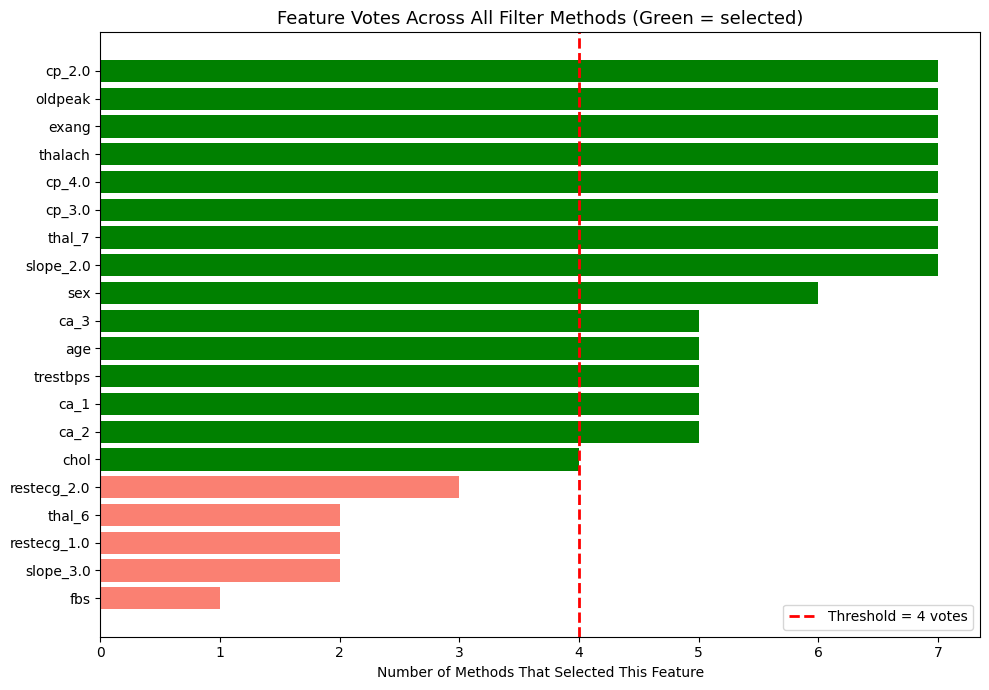


✅ Saved to saved_data/
   filter_selected_features.pkl → 15 features
   X_train_filter.pkl           → shape (262, 15)
   X_test_filter.pkl            → shape (61, 15)

➡️  Next: 06_wrapper_feature_selection.ipynb


In [12]:
# ============================================================
# CELL 9 — Summary, Voting & Save
# ============================================================

summary = pd.DataFrame({'Feature': list(X_work_scaled.columns)})

summary['Variance_OK']   = summary['Feature'].isin(kept_after_variance)
summary['Chi2_Sig']      = summary['Feature'].isin(chi2_df[chi2_df['P_Value']   < 0.05]['Feature'])
summary['ANOVA_Sig']     = summary['Feature'].isin(anova_df[anova_df['P_Value'] < 0.05]['Feature'])
summary['Corr_OK']       = summary['Feature'].isin(corr_df[corr_df['Correlation'] >= 0.1]['Feature'])
summary['MI_OK']         = summary['Feature'].isin(mi_df[mi_df['MI_Score'] > 0.01]['Feature'])
summary['SelectK_ANOVA'] = summary['Feature'].isin(top_k_anova)
summary['SelectK_MI']    = summary['Feature'].isin(top_k_mi)

vote_cols = ['Variance_OK','Chi2_Sig','ANOVA_Sig','Corr_OK','MI_OK','SelectK_ANOVA','SelectK_MI']
summary['Votes'] = summary[vote_cols].sum(axis=1)
summary = summary.sort_values('Votes', ascending=False).reset_index(drop=True)

print("=" * 60)
print("📋 FILTER METHODS — FULL SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

VOTE_THRESHOLD = 4
final_features = summary[summary['Votes'] >= VOTE_THRESHOLD]['Feature'].tolist()

print("\n" + "=" * 60)
print(f"✅ FINAL SELECTED FEATURES (≥ {VOTE_THRESHOLD}/7 votes): {len(final_features)}")
print("=" * 60)
print(final_features)

# --- Chart ---
plt.figure(figsize=(10, 7))
colors = ['green' if v >= VOTE_THRESHOLD else 'salmon' for v in summary['Votes']]
plt.barh(summary['Feature'][::-1], summary['Votes'][::-1], color=colors[::-1])
plt.axvline(x=VOTE_THRESHOLD, color='red', linestyle='--',
            linewidth=2, label=f'Threshold = {VOTE_THRESHOLD} votes')
plt.title('Feature Votes Across All Filter Methods (Green = selected)', fontsize=13)
plt.xlabel('Number of Methods That Selected This Feature')
plt.legend()
plt.tight_layout()
plt.show()

# --- Save ---
SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

X_train_filter = X_train_scaled[final_features].copy()
X_test_filter  = X_test_scaled[final_features].copy()

joblib.dump(final_features,  f'{SAVE_DIR}/filter_selected_features.pkl')
joblib.dump(X_train_filter,  f'{SAVE_DIR}/X_train_filter.pkl')
joblib.dump(X_test_filter,   f'{SAVE_DIR}/X_test_filter.pkl')

print(f"\n✅ Saved to {SAVE_DIR}/")
print(f"   filter_selected_features.pkl → {len(final_features)} features")
print(f"   X_train_filter.pkl           → shape {X_train_filter.shape}")
print(f"   X_test_filter.pkl            → shape {X_test_filter.shape}")
print(f"\n➡️  Next: 06_wrapper_feature_selection.ipynb")